# Reconstructing reBAP from its own published formula

reBAP (the "Ausgleichsenergiepreis" / uniform balancing-energy price all
four German TSOs settle against) looks, from the outside, like a single
number per quarter-hour. netztransparenz.de publishes exactly how it's
built: three modules, and reBAP is simply whichever one points furthest
in the direction the system was actually out of balance.

```
reBAP = max(Module 1, Module 2, Module 3)   if NRV-Saldo was positive (short) that quarter-hour
      = min(Module 1, Module 2, Module 3)   if negative (long)
```

| Module | NRV-Saldo's role | Module-specific input |
|---|---|---|
| **1 (base)** | indirect -- determines *how much* aFRR/mFRR had to be activated, i.e. which bid gets "pulled" | **Activation price** of aFRR/mFRR (the European PICASSO/MARI platforms) -- real, settled cost of the reserve power actually called |
| **2 (incentivising)** | direct -- sign picks add/subtract, magnitude (saturating at 500 MW average power per quarter-hour) sets the distance's size | **ID-AEP** (continuous-intraday volume-weighted price index) as the anchor |
| **3 (scarcity)** | direct -- is itself the parabola's variable, and an 80%-of-dimensioned-reserve threshold is the on/off switch | no external market price -- a self-contained penalty, capped at 2x the maximum intraday bid price (currently 19,998 EUR/MWh) |

netztransparenz.de publishes all four series directly: reBAP itself, the
underlying NRV-Saldo (system imbalance, MW), and -- found while
prototyping this page in `energy-research` -- the three AEP modules
themselves, already computed. This page asks the obvious next question:
does `max`/`min` of the three published modules actually reproduce
published reBAP?

Prototyped in `energy-research`'s exploratory pipeline before being
rebuilt here against this hub's own `rebap_price`/`nrv_saldo`/`id_aep`/
`aep_modules` assets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from insights.paths import hub_file

MAIN_COLOR = "#2a78d6"     # dataviz skill default categorical slot 1 (blue) -- actual/reconstructed reBAP
MODULE1_COLOR = "#eb6834"  # slot 2 (orange)
MODULE2_COLOR = "#1baf7a"  # slot 3 (aqua)
MODULE3_COLOR = "#eda100"  # slot 4 (yellow)
NEUTRAL = "#9a9990"

## Data

From 2022-06-22 onward -- the AEP-Module series' own start (reBAP and
NRV-Saldo both go back to 2014, but the module-based calculation
methodology itself only took effect per a 2022-04-28 BNetzA decision).

In [2]:
rebap = pd.read_parquet(hub_file("balancing_market", "rebap_price.parquet"))
rebap.index = pd.to_datetime(rebap.index)

nrv = pd.read_parquet(hub_file("balancing_market", "nrv_saldo.parquet"))
nrv.index = pd.to_datetime(nrv.index)

modules = pd.read_parquet(hub_file("balancing_market", "aep_modules.parquet"))
modules.index = pd.to_datetime(modules.index)

panel = pd.DataFrame({
    "rebap": rebap["rebap_eur_mwh"],
    "nrv_saldo_mw": nrv["nrv_saldo_mw"],
    "module1": modules["aep_module1_eur_mwh"],
    "module2": modules["aep_module2_eur_mwh"],
    "module3": modules["aep_module3_eur_mwh"],
}).dropna(subset=["rebap", "nrv_saldo_mw", "module1", "module2"])  # module3 allowed NaN -- "doesn't apply" is the normal case
panel["balance_gcc_mwh"] = panel["nrv_saldo_mw"] * 0.25

print(f"{len(panel):,} quarter-hours, {panel.index.min()} -> {panel.index.max()}")
print(f"Module 3 genuinely active: {panel['module3'].notna().mean():.2%} of quarter-hours")

148,696 quarter-hours, 2022-06-22 00:00:00 -> 2026-09-17 21:45:00
Module 3 genuinely active: 0.02% of quarter-hours


`aep_modules`' Module 3 column already has a real raw-data quirk
corrected before it ever reaches this page (see the hub's own
`edh/aep_modules.py`): netztransparenz.de encodes "Module 3 doesn't
apply" as a literal `0.0` 99.93% of the time, not the `N.E.` placeholder
the formula's own wording ("the scarcity component has no effect" below
threshold) would suggest -- treating that zero as a real candidate value
would make it win nearly every `min()` comparison on an over-supplied
quarter-hour, dragging a naive reconstruction toward 0 whenever Module 1
or 2 actually set the price. Confirmed empirically while finding this:
it dropped an earlier, uncorrected version of this reconstruction's match
rate from 99.99% to 89.6%.

## The reconstruction

In [3]:
mstack = panel[["module1", "module2", "module3"]].to_numpy()
short = (panel["balance_gcc_mwh"] > 0).to_numpy()
long_ = (panel["balance_gcc_mwh"] < 0).to_numpy()

reconstructed = np.where(
    short, np.nanmax(mstack, axis=1),
    np.where(long_, np.nanmin(mstack, axis=1), panel["module2"].to_numpy()),
)
panel["reconstructed"] = reconstructed
panel["diff"] = panel["rebap"] - panel["reconstructed"]

exact = (panel["diff"].abs() < 0.02).mean()
close = (panel["diff"].abs() < 1.00).mean()
print(f"Exact match (tolerance 0.02 EUR/MWh): {exact:.2%}")
print(f"Close match (tolerance 1.00 EUR/MWh):  {close:.2%}")

Exact match (tolerance 0.02 EUR/MWh): 99.99%
Close match (tolerance 1.00 EUR/MWh):  100.00%


## Actual vs. reconstructed, and which module actually sets the price

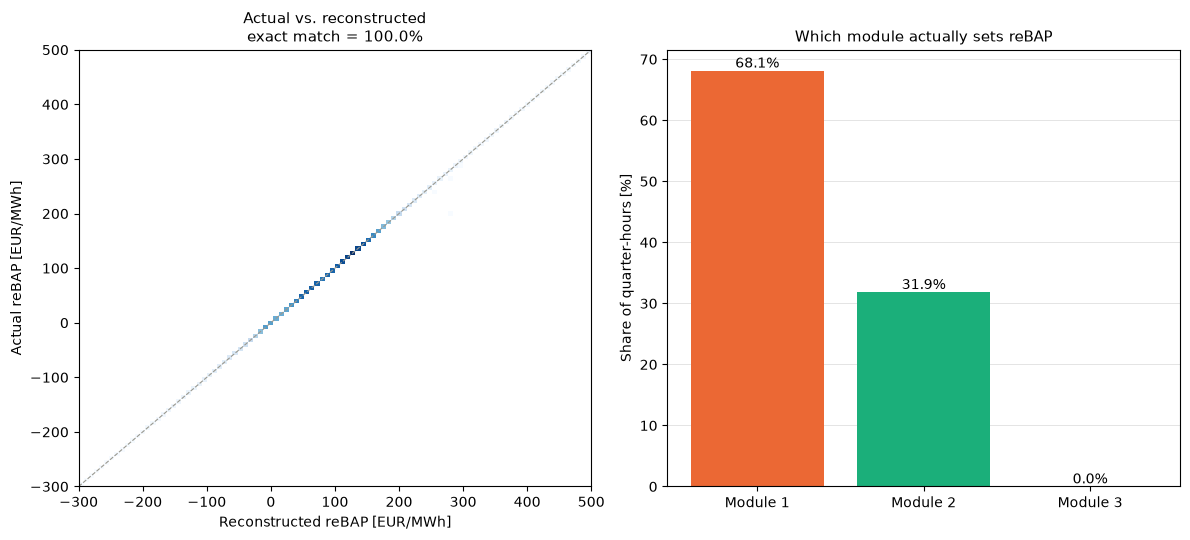

In [4]:
masked_max = np.where(np.isnan(mstack), -np.inf, mstack)
masked_min = np.where(np.isnan(mstack), np.inf, mstack)
winner_code = np.where(short, np.argmax(masked_max, axis=1), np.where(long_, np.argmin(masked_min, axis=1), 1))
panel["winner"] = pd.Categorical.from_codes(winner_code, categories=["Module 1", "Module 2", "Module 3"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

ax = axes[0]
lo, hi = -300, 500
ax.hist2d(panel["reconstructed"], panel["rebap"], bins=100, range=[[lo, hi], [lo, hi]], cmap="Blues", cmin=1)
ax.plot([lo, hi], [lo, hi], color=NEUTRAL, linewidth=0.8, linestyle="--")
ax.set_xlabel("Reconstructed reBAP [EUR/MWh]")
ax.set_ylabel("Actual reBAP [EUR/MWh]")
ax.set_title(f"Actual vs. reconstructed\nexact match = {exact:.1%}", fontsize=11)

ax = axes[1]
win_share = panel["winner"].value_counts().reindex(["Module 1", "Module 2", "Module 3"]) / len(panel) * 100
ax.bar(win_share.index, win_share.values, color=[MODULE1_COLOR, MODULE2_COLOR, MODULE3_COLOR])
for i, v in enumerate(win_share.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10)
ax.set_ylabel("Share of quarter-hours [%]")
ax.set_title("Which module actually sets reBAP", fontsize=11)
ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

`max`/`min(Module 1, Module 2, Module 3)` reconstructs real reBAP to a
near-exact match -- the scatter sits tight on the diagonal, and the
printed match rate confirms it isn't just visual. The small residual gap
is the one documented exception the formula itself carries: an actual
capacity-reserve (KapRes) activation overrides the plain `max`/`min` with
a separate rule, capped at twice the maximum intraday bid price -- not
modeled in this reconstruction.

The module win-share bar is new information, not visible from reBAP
alone: **Module 1 (the real aFRR/mFRR activation price) sets reBAP most
of the time**, Module 2 (the ID-AEP-anchored incentive) a meaningful
minority, and **Module 3 (the scarcity alarm) is genuinely rare** --
confirming it as an emergency mechanism, not a routine price-setter.

## Takeaway

reBAP is not a black box: it's `max`/`min` of three transparently
published, independently sourced signals -- a real observed reserve-
activation cost, a calibrated distance from the intraday spot price, and
a scarcity penalty that only engages near the edge of available reserve
capacity. All three, plus the underlying system imbalance (NRV-Saldo)
itself, are now ingested by this hub (`balancing_market` asset group),
so this reconstruction -- and the module win-share breakdown above -- can
be re-run against the latest published data at any time, not just
reproduced once from a historical snapshot.